#Classification Project

##Import Libraries

In [1]:
import numpy as np
import pandas as pd
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix
from scipy.stats import norm, skew

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, precision_score,
    recall_score, fbeta_score,
    classification_report, roc_curve, auc, roc_auc_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    cross_val_score, GridSearchCV, ShuffleSplit, KFold
)

import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
%matplotlib inline
color = sns.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display

import random
from datetime import datetime
import string

# Configure Environment
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import os
#default_dir = "/content/drive/MyDrive/Documents/DigitalSkola/Conqueror Project"
#os.chdir(default_dir)

In [ ]:
dataset = pd.read_csv('data/raw/customer_churn_data.csv')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,"7,043.00","7,043.00","7,043.00"
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [ ]:
dataset[dataset['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
dataset['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [ ]:
column_category = [
    'OnlineSecurity',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for column in column_category:
    print(f"These are the unique values in column {column}: {dataset[column].unique()}")

These are the unique values in column OnlineSecurity: ['No' 'Yes' 'No internet service']
These are the unique values in column DeviceProtection: ['No' 'Yes' 'No internet service']
These are the unique values in column TechSupport: ['No' 'Yes' 'No internet service']
These are the unique values in column StreamingTV: ['No' 'Yes' 'No internet service']
These are the unique values in column StreamingMovies: ['No' 'Yes' 'No internet service']


In [ ]:
dataset.duplicated(subset=['customerID']).sum()

np.int64(0)

* TotalCharges is meant to be Numerical, but is detected as object. This is caused by empty strings " ". We can replace it with "0" because their tenure is 0
* MultipleLines has similar values "No phone service" and "No". So we should standardize it to "No"
* The same goes for columns OnlineSecurity, DeviceProtection,TechSupport, StreamingTV, StreamingMovies, with values "No internet service" and "No". So we should also standardize it to "No"

## Data Cleaning and Handling

In [ ]:
dataset['TotalCharges'] = dataset['TotalCharges'].replace(' ','0')

In [ ]:
dataset['TotalCharges']  = pd.to_numeric(dataset['TotalCharges'], errors = 'coerce')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset['MultipleLines'] = dataset['MultipleLines'].replace('No phone service','No')

In [ ]:
dataset['MultipleLines'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
column_category

['OnlineSecurity',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']

In [ ]:
dataset[column_category] = dataset[column_category].replace('No internet service','No')

In [ ]:
dataset['OnlineSecurity'].unique()

array(['No', 'Yes'], dtype=object)

##EDA

In [ ]:
dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,"1,889.50",No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,"1,840.75",No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,"1,990.50",No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,"7,362.90",No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


###Data Distribution

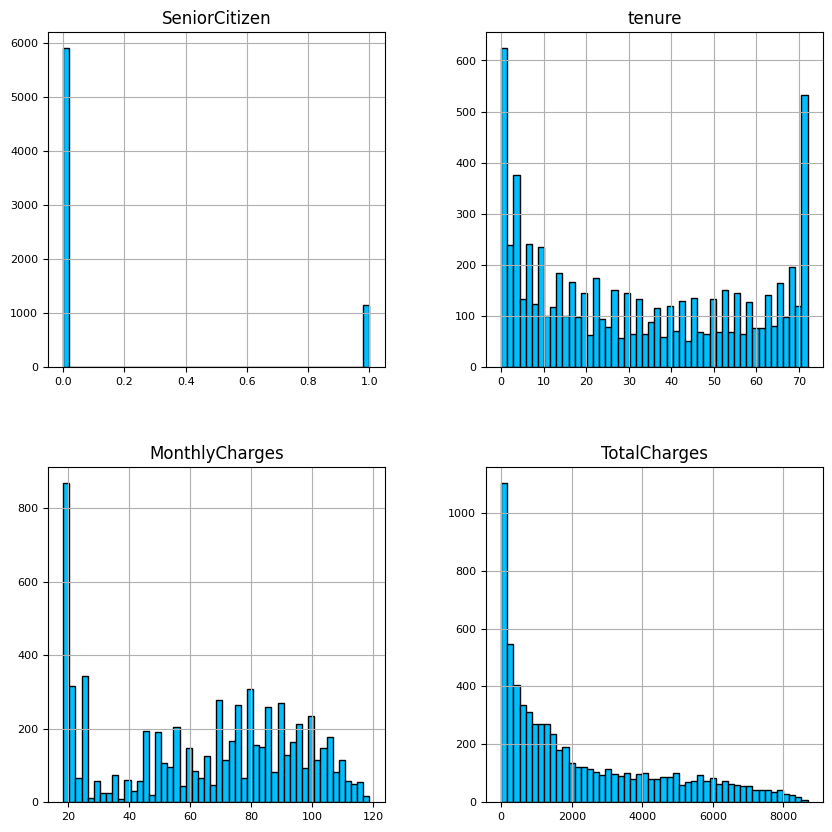

In [ ]:
# Show the distribution of the numerical features
fig_ = dataset.hist(
    figsize=(10, 10),
    bins=50,
    color="deepskyblue",
    edgecolor="black",
    xlabelsize=8,
    ylabelsize=8
)

**Insights**
*   SeniorCitizen: There are very few Senior Citizens among the customer base. Might be because Senior Citizens mostly churn.
*   tenure: There is a high number of customers who have 0 tenure and the max tenure value (70), very few customers fall in between those numbers. This indicates that there is a healthy stream of customers coming in and a high number of very loyal customers. So customers either leave relatively early or stay for very long.
*   MonthlyCharges: A high amount of customers spend around 20 dollars, which might indicate that most customers subscribe to the most basic plan. Additionally, there is a decent spread of mothly charges which suggests that customers mostly spend based on the predetermined subscription plans.
*   TotalCharges: Most customers spend a low amount of money (0-1000 dollars), which might be due to the high amount of new customers. The amount of customers consistently decreses as the total charges increase, which might suggest that most customers churn before accumulating high spendings on the service.  


###Boxplot Analysis of Numerical Features by Churn

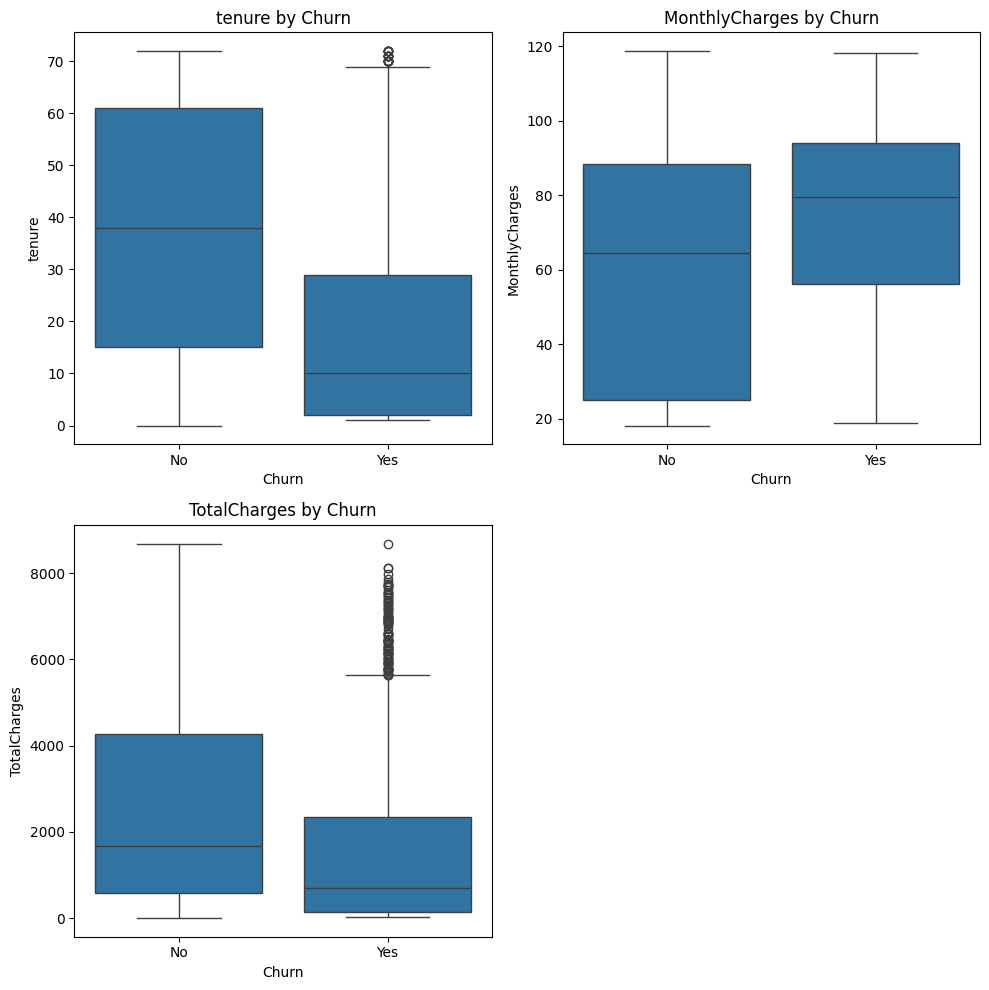

In [ ]:
#'SeniorCitizen' is not included as it is actually a categorical feature
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        x='Churn',
        y=feature,
        data=dataset,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Churn')

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

**Insights**
*   MonthlyCharges VS Churn: Customers paying higher monthly fees appear more likely to discontinue the service. This may suggest that customers perceive high-priced plans as less valuable or are more sensitive to pricing.
*   TotalCharges VS Churn: Customers who remain with the company accumulate higher total charges over time, whereas customers who churn tend to leave before generating substantial lifetime revenue.
*   Tenure vs Churn: Customer churn occurs mostly among newer customers, while long-term customers are considerably more likely to remain with the company.



###Correlation Heatmap

In [ ]:
dataset['Churn'] = dataset['Churn'].map({'Yes':1,'No':0})

In [ ]:
num_target_features = numerical_features
num_target_features.append('Churn')

In [ ]:
# Define the heatmap parameters
pd.options.display.float_format = "{:,.2f}".format

# Define correlation matrix
corr_matrix = dataset[num_target_features].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.00,0.25,0.83,-0.35
MonthlyCharges,0.25,1.00,0.65,0.19
TotalCharges,0.83,0.65,1.00,-0.20
Churn,-0.35,0.19,-0.20,1.00


In [ ]:
# Mask the upper part of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
mask

array([[ True,  True,  True,  True],
       [False,  True,  True,  True],
       [False, False,  True,  True],
       [False, False, False,  True]])

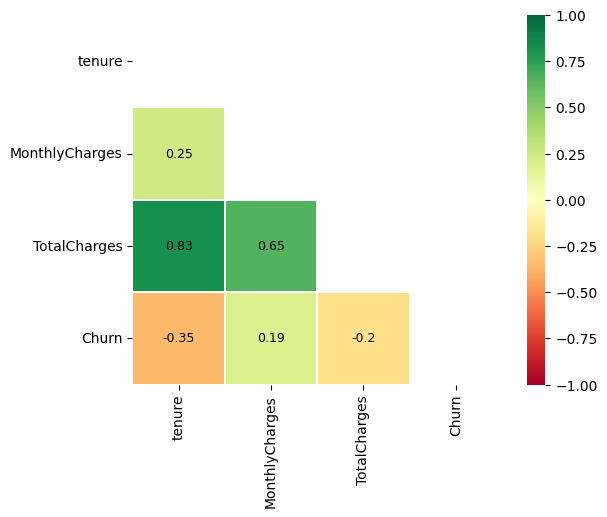

In [ ]:
# Choose the color map
cmap = "RdYlGn"

# Plot the heatmap
sns.heatmap(
    data=corr_matrix,
    mask=mask, # cover, not showing them which masked True
    vmax=1.0,
    vmin=-1.0,
    linewidths=0.1,
    annot_kws={
        "size": 9,
        "color": "black"
    },
    square=True,
    cmap=cmap,
    annot=True
);

**Insights**
*   TotalCharges has a high correlation with tenure and MonthlyCharges, which confirms that it most likely shows the same information with them. TotalCharges can be dropped from the numerical features.
*   None of the numerical features show a strong correlation with Churn, but tenure does show a moderate correlation. This might mean that the numerical features might not be the strongest predictors of Churn.

###Count plots of categorical variables

In [ ]:
categorical_features = []
for feat, feat_type in zip(dataset.columns, dataset.dtypes):
    if feat_type == 'object':
       categorical_features.append(feat)

# Train set
dataset_categ = dataset[categorical_features]

In [ ]:
dataset_categ.drop(columns='customerID', inplace=True)

In [ ]:
len(dataset_categ.columns)

15

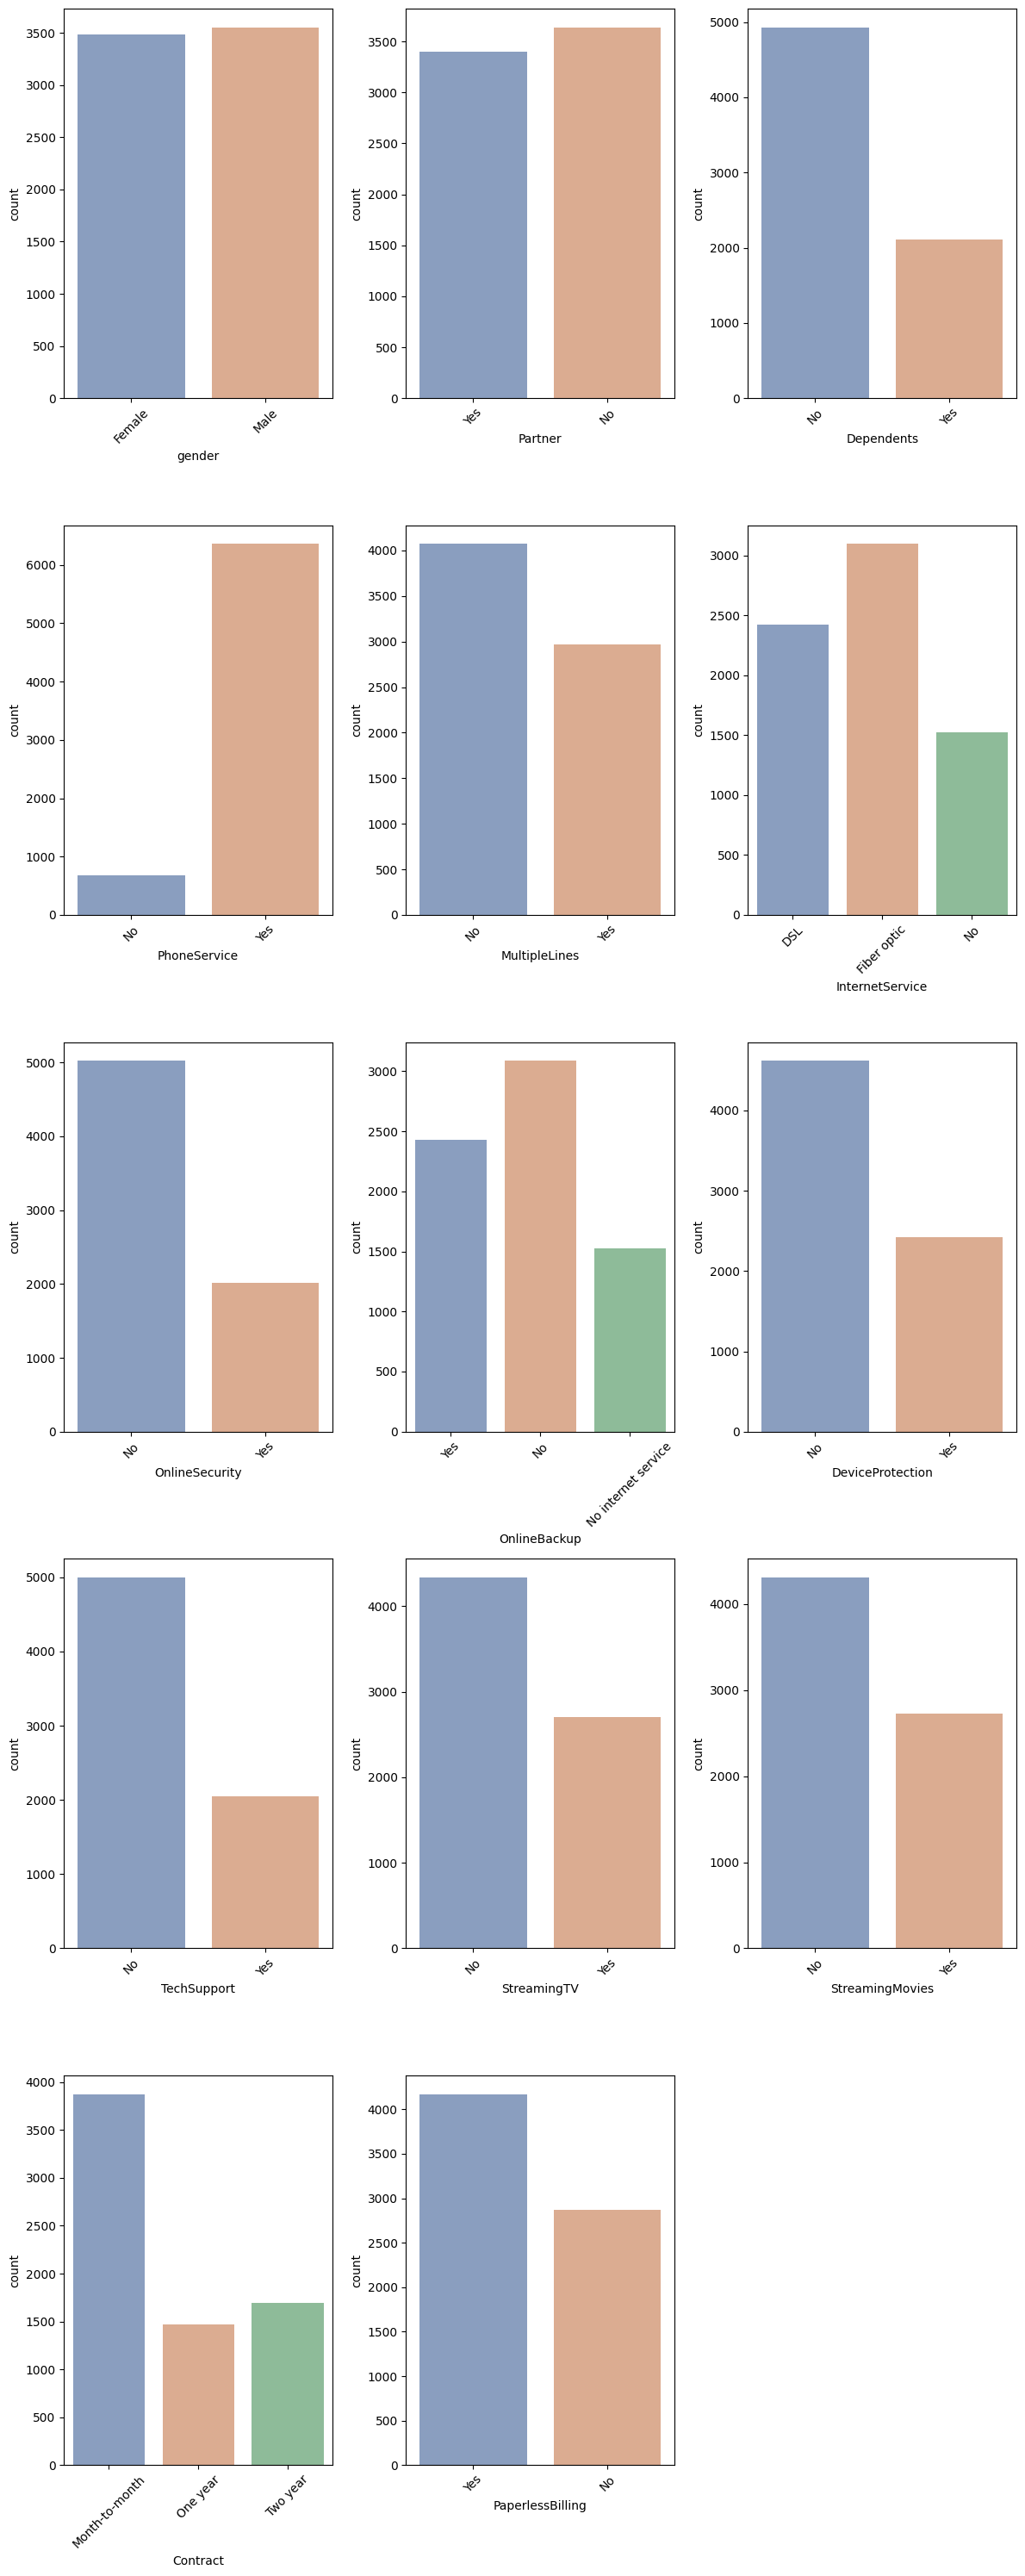

In [ ]:
fig, axes = plt.subplots(
    nrows=round(len(dataset_categ.columns) / 3),
    ncols=3,
    figsize=(12, 30)
)

for i, ax in enumerate(axes.flatten()):  # Iterate through flattened axes array
    if i < (len(dataset_categ.columns)-1): # -1 because we exclude Churn

        sns.countplot(
            x=dataset_categ.columns[i],
            alpha=0.7,
            data=dataset_categ,
            palette="deep",
            ax=ax
        )

        ax.tick_params(
            axis='x',
            rotation=45
        )
    else:
        ax.set_axis_off() # Hide empty subplots

fig.tight_layout()
plt.show()

**Insights**
*   None of the categorical features are dominated by one category with an exception of the PhoneService feature, which show that almost all the customers subscribed to the PhoneService feature. This is is understandable as this should be the most basic service in a telecommunication service.



###Proportion of Churn Rate in Categorical Features

In [ ]:
categorical_features

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [ ]:
categorical_features.remove('customerID')

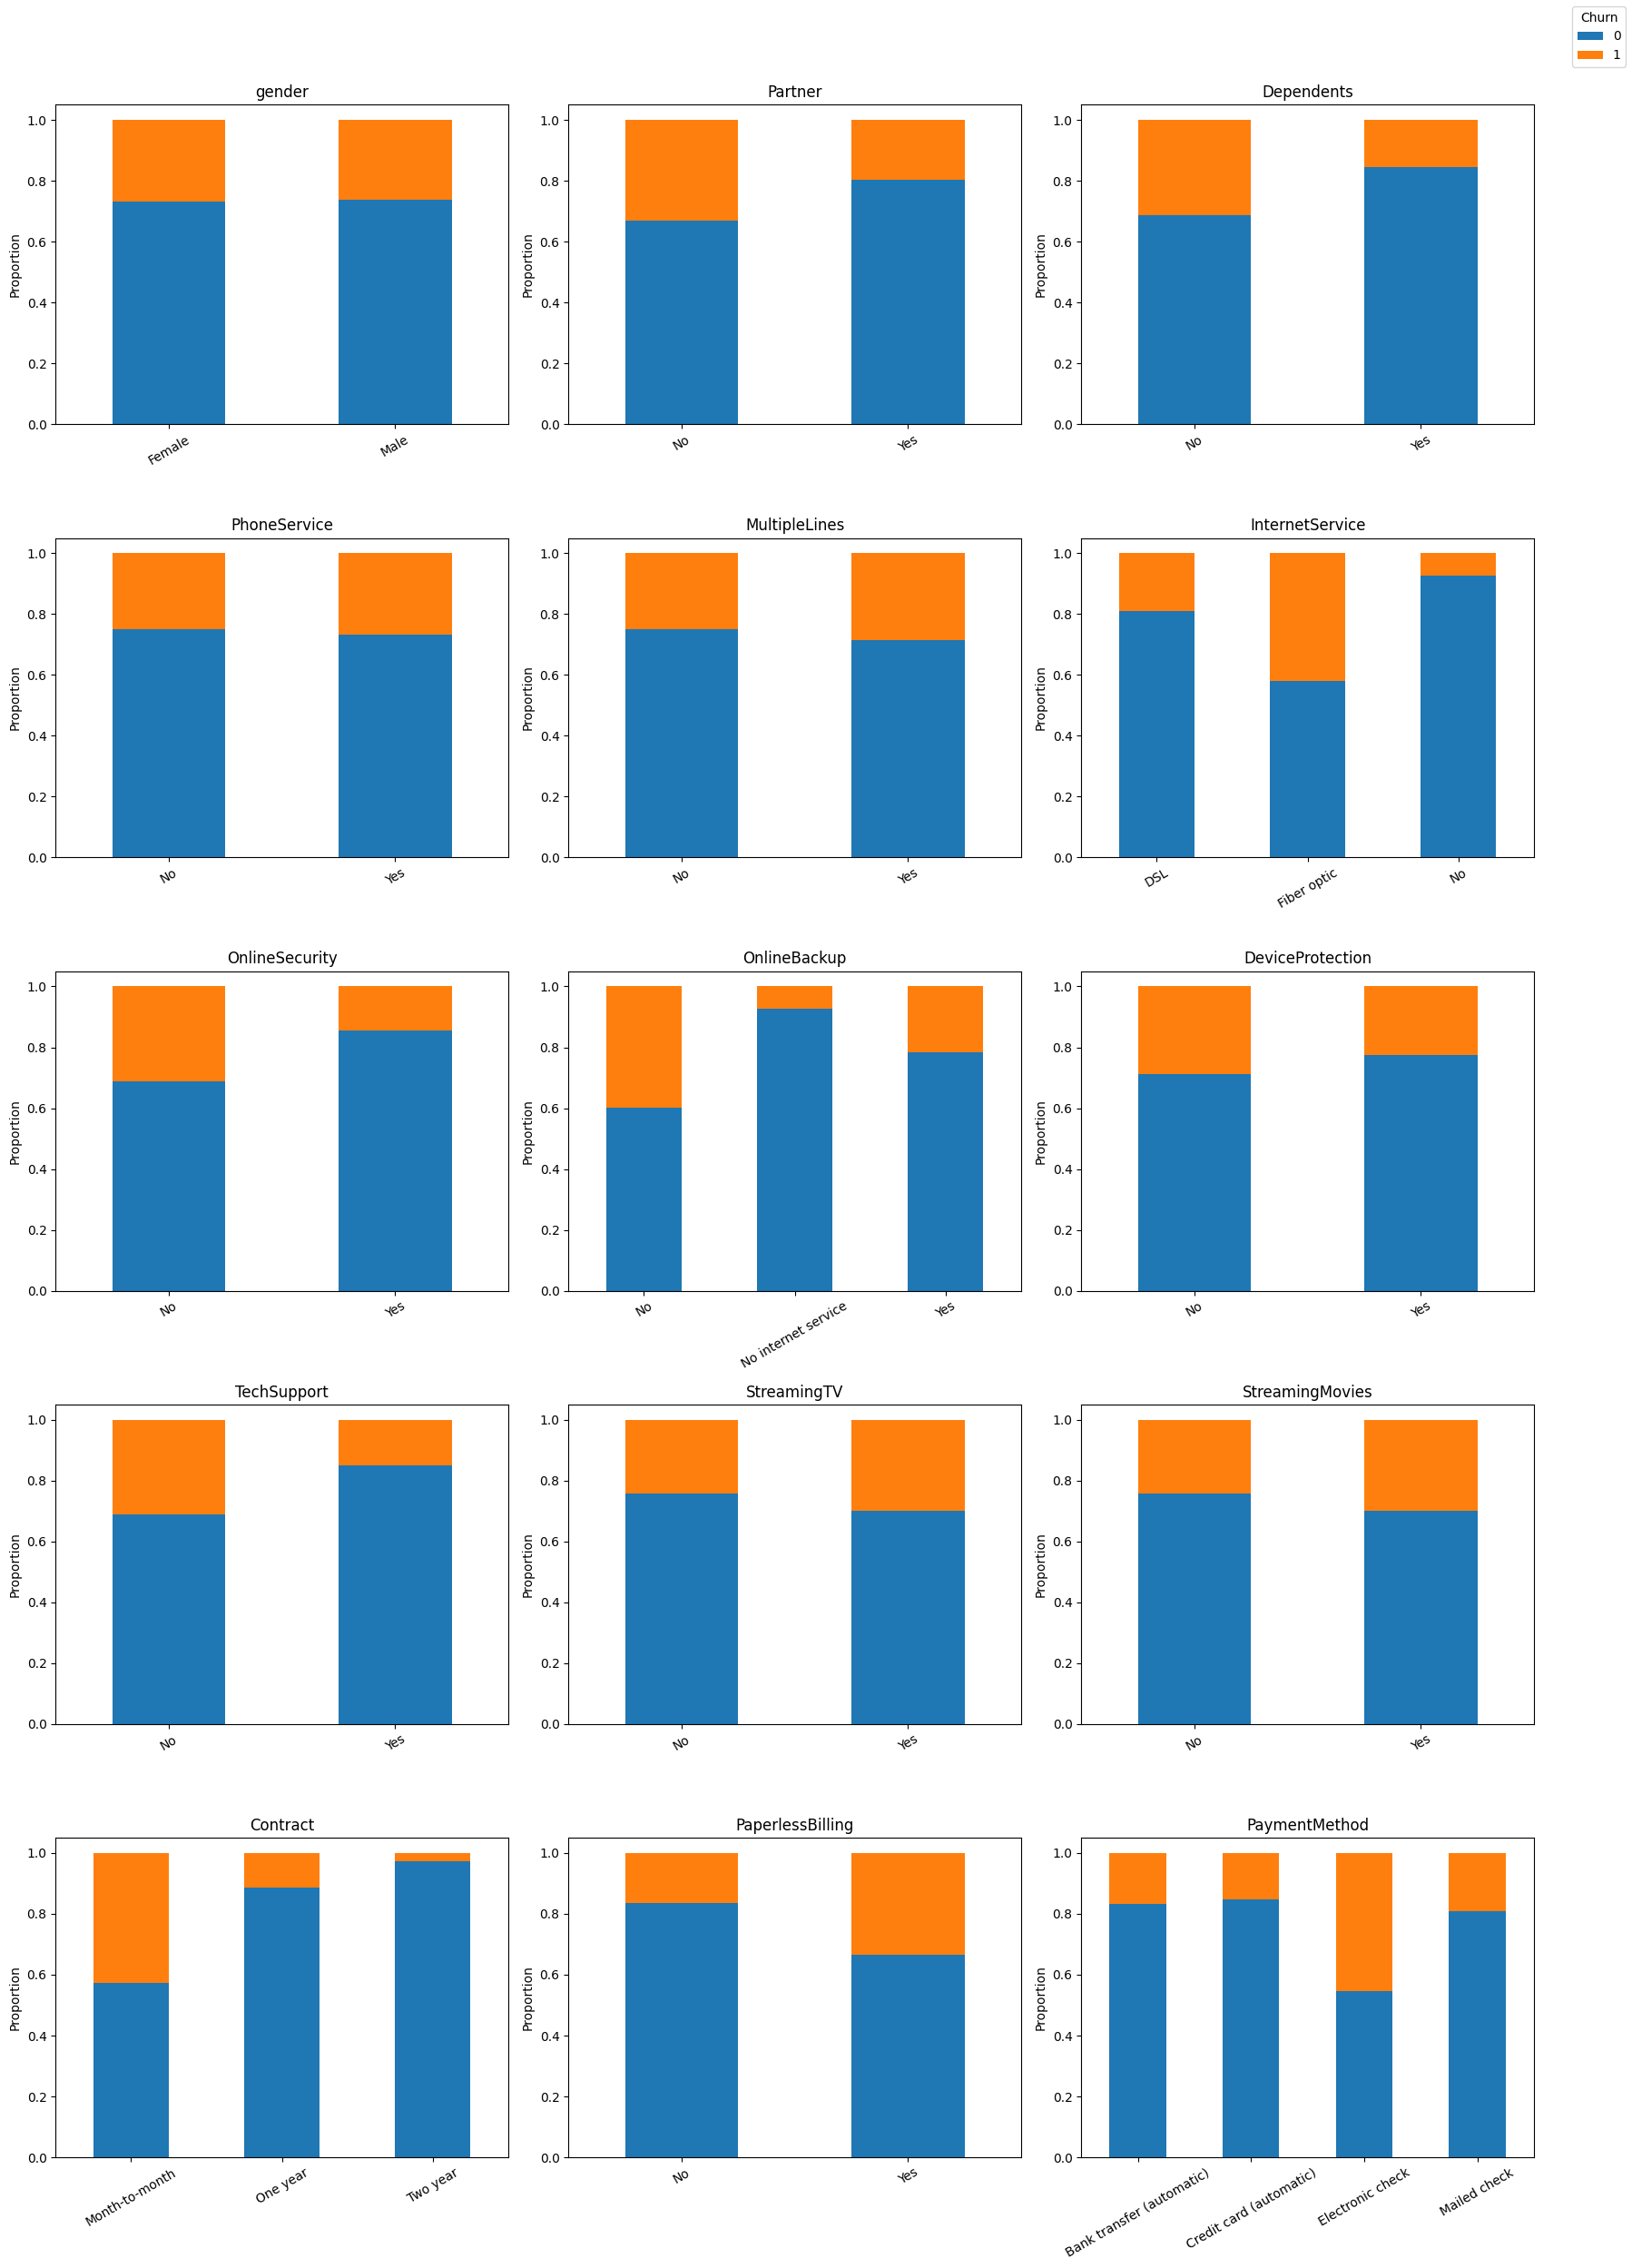

In [ ]:
# Layout
n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, ax in enumerate(axes.flatten()):
    if i < (len(categorical_features)):
      # Calculate proportion of churn within each category
      crosstab = pd.crosstab(
          dataset[categorical_features[i]],
          dataset['Churn'],
          normalize='index'
      )

      crosstab.plot(
          kind='bar',
          stacked=True,
          ax=axes[i],
          legend=False
      )

      axes[i].set_title(categorical_features[i])
      axes[i].set_xlabel('')
      axes[i].set_ylabel('Proportion')
      axes[i].tick_params(axis='x', rotation=30)
    else:
        ax.set_axis_off() # Hide empty subplots

# Remove any unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# Create one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Churn', loc='upper right')

plt.tight_layout(rect=[0, 0, 0.95, 0.97])
plt.show()

**Insights**
*   The most visible and explainable categorical feature vs churn rate is in the Contract feature, where the longer the contract duration is, the less likely a customer is to Churn.

Note: 100% Stacked Bar Charts aren't very good at visualizing Churn Rates.

In [ ]:
pd.crosstab(
          dataset['Contract'],
          dataset['Churn'],
          normalize='index'
      )

Churn,0,1
Contract,,
Month-to-month,0.57,0.43
One year,0.89,0.11
Two year,0.97,0.03


A normal crosstab is better at indicating the proportions of a category vs the Churn rate.

In [ ]:
dataset['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
dataset.groupby('Churn')['tenure'].mean().reset_index()

,Churn,tenure
0,0,37.57
1,1,17.98


In [ ]:
dataset[['Contract','Churn']].value_counts()

Contract        Churn
Month-to-month  0        2220
                1        1655
Two year        0        1647
One year        0        1307
                1         166
Two year        1          48
Name: count, dtype: int64

##Feature Engineering

In [ ]:
# dataset['Churn'] = dataset['Churn'].map({'Yes':1,'No':0})

In [ ]:
dataset.drop(columns = ['customerID'], inplace=True)

In [ ]:
dataset['SeniorCitizen'] = dataset['SeniorCitizen'].map({1:'Yes',0:'No'})

##One Hot Encoding and Label Encoding

In [ ]:
dataset = pd.get_dummies(dataset, columns = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','PaymentMethod'], dtype =int)

In [ ]:
dataset['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
dataset['Contract'] = dataset['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})

##Feature Selection

In [ ]:
X = dataset.drop(columns =['Churn'])
y = dataset['Churn']

In [ ]:
selector = SelectKBest(score_func=chi2, k=4)
X_new = selector.fit_transform(X, y)
feature_scores = selector.scores_
selected_features = X.columns[selector.get_support()]
print("Feature Scores:", feature_scores)
print("Selected Features:", selected_features)

Feature Scores: [1.62789237e+04 1.11578017e+03 3.68078770e+03 6.24292003e+05
 2.63667886e-01 2.58698618e-01 2.60005870e+01 1.34351545e+02
 7.70024458e+01 8.24120826e+01 5.69038910e+01 1.33036443e+02
 9.07147852e-01 9.72606249e-02 4.77790470e+00 6.54851159e+00
 7.13131803e+01 3.74476216e+02 2.86520193e+02 5.91939365e+01
 1.47295858e+02 2.84074903e+02 2.86520193e+02 3.12176940e+01
 1.06013798e+01 2.02266622e+01 5.54279247e+01 1.35559783e+02
 1.08219035e+01 1.73342348e+01 1.02933412e+01 1.62425307e+01
 1.53480111e+02 1.05680863e+02 7.64859132e+01 9.95820574e+01
 4.26422767e+02 4.56515896e+01]
Selected Features: Index(['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges'], dtype='object')


##Train Test Split

In [ ]:
X_new = dataset[['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']]
y_new = dataset['Churn']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify = y
)

##Scaling Train and Test Dataset

In [ ]:
# Train
sc_X = StandardScaler()
X_tr_columns = X_train.columns
X_tr_idx = X_train.index
X_train = pd.DataFrame(
    sc_X.fit_transform(X_train),
    columns=X_tr_columns,
    index=X_tr_idx
)

# Test
X_ts_columns = X_test.columns
X_ts_idx = X_test.index
X_test = pd.DataFrame(
    sc_X.transform(X_test),
    columns=X_ts_columns,
    index=X_ts_idx
)

##Machine Learning Modeling

In [ ]:
models = []
models.append(
    (
        'Logistic Regression',
        LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        )
    )
)
models.append(
    (
        'Random Forest',
        RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
    )
)
models.append(
    (
        'Decision Tree',
        DecisionTreeClassifier(
            criterion='entropy',
            random_state=42
        )
    )
)

models.append(('SVM', SVC(class_weight='balanced', probability=True, random_state=42)))
models.append(('Naive Bayes', GaussianNB()))
models.append(('KNN', KNeighborsClassifier()))

acc_results = []
auc_results = []
names = []

col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns = col)

i = 0
for name, model in models:
    kfold = KFold(n_splits = 10) # 10 Cross validation
    cv_acc_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
    cv_auc_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] =[
        name,
        round(cv_auc_results.mean() * 100, 2),
        round(cv_auc_results.std() * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ]
    i += 1
model_results.sort_values(
    by=['ROC AUC Mean'],
    ascending = False
)

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,82.73,1.97,72.65,2.20
3,SVM,81.04,2.12,70.57,2.46
4,Naive Bayes,80.83,1.53,70.43,2.36
1,Random Forest,79.37,2.29,76.50,1.77
5,KNN,78.19,1.86,77.23,1.55
2,Decision Tree,65.48,2.73,72.38,2.08


In [ ]:
Y_train.value_counts()

,count
Churn,
0,4139
1,1495


###Performing SMOTE to Counter Class Imbalance

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_train_sample, Y_train_sample = smote.fit_resample(X_train, Y_train)

In [ ]:
X_train_sample

,tenure,Contract,MonthlyCharges,TotalCharges
0,0.10,-0.83,-0.52,-0.26
1,-0.71,-0.83,0.34,-0.50
2,-0.79,1.57,-0.81,-0.75
3,-0.26,1.57,0.28,-0.17
4,-1.28,-0.83,-0.68,-0.99
...,...,...,...,...
8273,-0.96,-0.83,0.36,-0.72
8274,-0.83,-0.83,1.15,-0.49
8275,0.52,-0.83,1.18,1.07
8276,-1.24,-0.83,0.36,-0.95


In [ ]:
Y_train_sample.value_counts()

,count
Churn,
0,4139
1,4139


###Post-SMOTE Machine Learning Modeling

In [ ]:
models = []
models.append(
    (
        'Logistic Regression',
        LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        )
    )
)

models.append(
    (
        'Random Forest',
        RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
    )
)

models.append(
    (
        'Decision Tree',
        DecisionTreeClassifier(
            criterion='entropy',
            random_state=42
        )
    )
)


models.append(('SVM', SVC(class_weight='balanced', probability=True, random_state=42)))
models.append(('Naive Bayes', GaussianNB()))
models.append(('KNN', KNeighborsClassifier()))

acc_results = []
auc_results = []
names = []


col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns = col)


i = 0
for name, model in models:
    kfold = KFold(n_splits = 10) # 10 Cross validation
    cv_acc_results = cross_val_score(model, X_train_sample, Y_train_sample, cv=kfold, scoring='accuracy')
    cv_auc_results = cross_val_score(model,  X_train_sample, Y_train_sample, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] =[
        name,
        round(cv_auc_results.mean() * 100, 2),
        round(cv_auc_results.std() * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ]
    i += 1

model_results.sort_values(
    by=['ROC AUC Mean'],
    ascending = False
)

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,NaN,NaN,74.92,4.05
1,Random Forest,NaN,NaN,80.77,4.44
2,Decision Tree,NaN,NaN,77.23,3.34
3,SVM,NaN,NaN,74.67,6.20
4,Naive Bayes,NaN,NaN,72.05,6.95
5,KNN,NaN,NaN,77.70,4.67


In [ ]:
acc_results = []
auc_results = []
names = []

col = ['Algorithm', 'ROC AUC', 'Accuracy']
model_results = pd.DataFrame(columns = col)

i = 0
for name, model in models:
    model.fit(X_train_sample, Y_train_sample)
    y_pred = model.predict(X_test)
    acc_results.append(accuracy_score(Y_test, y_pred))
    auc_results.append(roc_auc_score(Y_test, y_pred))
    names.append(name)
    model_results.loc[i] =[
        name,
        round(roc_auc_score(Y_test, y_pred) * 100, 2),
        round(accuracy_score(Y_test, y_pred) * 100, 2),
    ]
    i += 1

model_results.sort_values(
    by=['ROC AUC'],
    ascending = False
)

,Algorithm,ROC AUC,Accuracy
3,SVM,74.79,70.62
0,Logistic Regression,74.55,71.89
4,Naive Bayes,73.86,67.99
5,KNN,70.33,71.97
1,Random Forest,69.57,74.24
2,Decision Tree,65.55,70.33


##Hyperparameter Tuning and Optimization

###Logistic Regression

In [ ]:
tuned_parameters_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [500, 1000]
}

# GridSearch
logreg_cv = GridSearchCV(LogisticRegression(random_state=42), tuned_parameters_lr, cv=10, n_jobs=-1, verbose=1)

# fit the GridSearch on train set
logreg_cv.fit(X_train_sample, Y_train_sample)

# print best params and the corresponding Accuracy
print(f"Best hyperparameters: {logreg_cv.best_params_}")
print(f"Best Accuracy Score (train): {logreg_cv.best_score_}")

Fitting 10 folds for each of 48 candidates, totalling 480 fits
Best hyperparameters: {'C': 10, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy Score (train): 0.7498143864383809


In [ ]:
# Logistic Regression with the best hyperparameters
logreg_mod = LogisticRegression(
    C=logreg_cv.best_params_["C"],
    penalty=logreg_cv.best_params_["penalty"],
    solver=logreg_cv.best_params_["solver"],
    max_iter=logreg_cv.best_params_["max_iter"],
    )

# Fit the model on train set
logreg_mod.fit(X_train_sample, Y_train_sample)

# Predict on test set
y_pred = logreg_mod.predict(X_test)

print(f"- {logreg_mod.__class__.__name__}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_pred)}")
print(f"F1-Score: {f1_score(Y_test, y_pred)}")
print(f"accuracy: {accuracy_score(Y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}")

- LogisticRegression
ROC AUC: 0.7463677697693043
F1-Score: 0.6032064128256514
accuracy: 0.7189496096522356
Confusion Matrix:
[[712 323]
 [ 73 301]]


In [ ]:
# Save the model results into lists
model_list = []
accuracy_list = []
f1score_list = []
roc_auc_list = []

In [ ]:
model_list.append(logreg_mod.__class__.__name__)
accuracy_list.append(round(accuracy_score(Y_test, y_pred), 4))
f1score_list.append(round(f1_score(Y_test, y_pred), 4))
roc_auc_list.append(round(roc_auc_score(Y_test, y_pred), 4))

###Decision Tree

In [ ]:
tuned_parameters_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearch
dt_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), tuned_parameters_dt, cv=10, n_jobs=-1, verbose=1)

# fit the GridSearch on train set
dt_cv.fit(X_train_sample, Y_train_sample)

# print best params and the corresponding Accuracy
print(f"Best hyperparameters: {dt_cv.best_params_}")
print(f"Best Accuracy (train): {dt_cv.best_score_}")

Fitting 10 folds for each of 864 candidates, totalling 8640 fits
Best hyperparameters: {'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Accuracy (train): 0.7843668401591224


In [ ]:
# Decision Tree with the best hyperparameters
dt_mod = DecisionTreeClassifier(
    criterion=dt_cv.best_params_["criterion"],
    max_depth=dt_cv.best_params_["max_depth"],
    min_samples_split=dt_cv.best_params_["min_samples_split"],
    min_samples_leaf=dt_cv.best_params_["min_samples_leaf"],
    max_features=dt_cv.best_params_["max_features"],
    )

# Fit the model on train set
dt_mod.fit(X_train_sample, Y_train_sample)

# Predict on test set
y_pred = dt_mod.predict(X_test)

print(f"- {dt_mod.__class__.__name__}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_pred)}")
print(f"F1-Score: {f1_score(Y_test, y_pred)}")
print(f"accuracy: {accuracy_score(Y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}")

- DecisionTreeClassifier
ROC AUC: 0.6852191996693275
F1-Score: 0.5364758698092031
accuracy: 0.7068843151171044
Confusion Matrix:
[[757 278]
 [135 239]]


In [ ]:
model_list.append(dt_mod.__class__.__name__)
accuracy_list.append(round(accuracy_score(Y_test, y_pred), 4))
f1score_list.append(round(f1_score(Y_test, y_pred), 4))
roc_auc_list.append(round(roc_auc_score(Y_test, y_pred), 4))

###Random Forest

In [ ]:
tuned_parameters_rf = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearch
rf_cv = GridSearchCV(RandomForestClassifier(random_state=42), tuned_parameters_rf, cv=10, n_jobs=-1, verbose=1)

# fit the GridSearch on train set
rf_cv.fit(X_train_sample, Y_train_sample)

# print best params and the corresponding Accuracy
print(f"Best hyperparameters: {rf_cv.best_params_}")
print(f"Best Accuracy (train): {rf_cv.best_score_}")

Fitting 10 folds for each of 864 candidates, totalling 8640 fits
Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Accuracy (train): 0.8140891061925707


In [ ]:
# Random Forest with the best hyperparameters
rf_mod = RandomForestClassifier(
    criterion=rf_cv.best_params_["criterion"],
    max_depth=rf_cv.best_params_["max_depth"],
    min_samples_split=rf_cv.best_params_["min_samples_split"],
    min_samples_leaf=rf_cv.best_params_["min_samples_leaf"],
    max_features=rf_cv.best_params_["max_features"],
    )

# Fit the model on train set
rf_mod.fit(X_train_sample, Y_train_sample)

# Predict on test set
y_pred = rf_mod.predict(X_test)

print(f"- {rf_mod.__class__.__name__}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_pred)}")
print(f"F1-Score: {f1_score(Y_test, y_pred)}")
print(f"accuracy: {accuracy_score(Y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}")

- RandomForestClassifier
ROC AUC: 0.7002066702833967
F1-Score: 0.5573366214549939
accuracy: 0.7452093683463449
Confusion Matrix:
[[824 211]
 [148 226]]


In [ ]:
model_list.append(rf_mod.__class__.__name__)
accuracy_list.append(round(accuracy_score(Y_test, y_pred), 4))
f1score_list.append(round(f1_score(Y_test, y_pred), 4))
roc_auc_list.append(round(roc_auc_score(Y_test, y_pred), 4))

###Support Vector Machine

In [ ]:
tuned_parameters_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

# GridSearch
svc_cv = GridSearchCV(SVC(random_state=42), tuned_parameters_svc, cv=10, n_jobs=-1, verbose=1)

# fit the GridSearch on train set
svc_cv.fit(X_train_sample, Y_train_sample)

# print best params and the corresponding Accuracy
print(f"Best hyperparameters: {svc_cv.best_params_}")
print(f"Best Accuracy (train): {svc_cv.best_score_}")

Fitting 10 folds for each of 48 candidates, totalling 480 fits
Best hyperparameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy (train): 0.7523507643598595


In [ ]:
# Support Vector Machine with the best hyperparameters
svc_mod = SVC(
    C=svc_cv.best_params_["C"],
    kernel=svc_cv.best_params_["kernel"],
    gamma=svc_cv.best_params_["gamma"],
    )

# Fit the model on train set
svc_mod.fit(X_train_sample, Y_train_sample)

# Predict on test set
y_pred = svc_mod.predict(X_test)

print(f"- {svc_mod.__class__.__name__}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_pred)}")
print(f"F1-Score: {f1_score(Y_test, y_pred)}")
print(f"accuracy: {accuracy_score(Y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}")

- SVC
ROC AUC: 0.7530858456689659
F1-Score: 0.6090373280943026
accuracy: 0.7175301632363378
Confusion Matrix:
[[701 334]
 [ 64 310]]


In [ ]:
model_list.append(svc_mod.__class__.__name__)
accuracy_list.append(round(accuracy_score(Y_test, y_pred), 4))
f1score_list.append(round(f1_score(Y_test, y_pred), 4))
roc_auc_list.append(round(roc_auc_score(Y_test, y_pred), 4))

###Naive Bayes

In [ ]:
tuned_parameters_nb = {
    'var_smoothing': np.logspace(0, -9, 10)
}

# GridSearch
nb_cv = GridSearchCV(GaussianNB(), tuned_parameters_nb, cv=10, n_jobs=-1, verbose=1)

# fit the GridSearch on train set
nb_cv.fit(X_train_sample, Y_train_sample)

# print best params and the corresponding Accuracy
print(f"Best hyperparameters: {nb_cv.best_params_}")
print(f"Best Accuracy (train): {nb_cv.best_score_}")

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best hyperparameters: {'var_smoothing': np.float64(0.001)}
Best Accuracy (train): 0.7252903223922097


In [ ]:
# Naive Bayes with the best hyperparameters
nb_mod = GaussianNB(
    var_smoothing=nb_cv.best_params_["var_smoothing"],
    )

# Fit the model on train set
nb_mod.fit(X_train_sample, Y_train_sample)

# Predict on test set
y_pred = nb_mod.predict(X_test)

print(f"- {nb_mod.__class__.__name__}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_pred)}")
print(f"F1-Score: {f1_score(Y_test, y_pred)}")
print(f"accuracy: {accuracy_score(Y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}")

- GaussianNB
ROC AUC: 0.7385814668423365
F1-Score: 0.5888787602552416
accuracy: 0.6799148332150461
Confusion Matrix:
[[635 400]
 [ 51 323]]


In [ ]:
model_list.append(nb_mod.__class__.__name__)
accuracy_list.append(round(accuracy_score(Y_test, y_pred), 4))
f1score_list.append(round(f1_score(Y_test, y_pred), 4))
roc_auc_list.append(round(roc_auc_score(Y_test, y_pred), 4))

###K-Nearest Neighbors

In [ ]:
tuned_parameters_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

# GridSearch
knn_cv = GridSearchCV(KNeighborsClassifier(), tuned_parameters_knn, cv=10, n_jobs=-1, verbose=1)

# fit the GridSearch on train set
knn_cv.fit(X_train_sample, Y_train_sample)

# print best params and the corresponding Accuracy
print(f"Best hyperparameters: {knn_cv.best_params_}")
print(f"Best Accuracy (train): {knn_cv.best_score_}")

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Best hyperparameters: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best Accuracy (train): 0.8087715916326399


In [ ]:
# K-Nearest Neighbors with the best hyperparameters
knn_mod = KNeighborsClassifier(
    n_neighbors=knn_cv.best_params_["n_neighbors"],
    weights=knn_cv.best_params_["weights"],
    metric=knn_cv.best_params_["metric"],
    p=knn_cv.best_params_["p"],
    )

# Fit the model on train set
knn_mod.fit(X_train_sample, Y_train_sample)

# Predict on test set
y_pred = knn_mod.predict(X_test)

print(f"- {knn_mod.__class__.__name__}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_pred)}")
print(f"F1-Score: {f1_score(Y_test, y_pred)}")
print(f"accuracy: {accuracy_score(Y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}")

- KNeighborsClassifier
ROC AUC: 0.688421297372704
F1-Score: 0.5407925407925408
accuracy: 0.7203690560681334
Confusion Matrix:
[[783 252]
 [142 232]]


In [ ]:
model_list.append(knn_mod.__class__.__name__)
accuracy_list.append(round(accuracy_score(Y_test, y_pred), 4))
f1score_list.append(round(f1_score(Y_test, y_pred), 4))
roc_auc_list.append(round(roc_auc_score(Y_test, y_pred), 4))

###Performance Evaluation

In [ ]:
model_results_cv = pd.DataFrame(
    {
        "Model": model_list,
        "ROC AUC": roc_auc_list,
        "Accuracy": accuracy_list,
        "F1-Score": f1score_list
    }
)

model_results_cv.sort_values(
    by=['ROC AUC'],
    ascending = False
)

,Model,ROC AUC,Accuracy,F1-Score
3,SVC,0.75,0.72,0.61
0,LogisticRegression,0.75,0.72,0.60
5,GaussianNB,0.74,0.68,0.59
2,RandomForestClassifier,0.70,0.75,0.56
4,KNeighborsClassifier,0.69,0.72,0.54
1,DecisionTreeClassifier,0.69,0.71,0.54


##Conclusion

Several machine learning models were evaluated for customer churn prediction, including Logistic Regression, Decision Tree, Random Forest, SVM, Naive Bayes, and K-Nearest Neighbors. Hyperparameter tuning produced only marginal improvements across the models, indicating that the baseline configurations were already well suited to the dataset. Among all models, SVM achieved the best overall performance with a ROC-AUC of 0.75 and an F1-score of 0.61, making it the most suitable model for this dataset. These findings suggest that the available customer features provide moderate predictive power and that further improvements are more likely to come from additional feature engineering or richer data rather than extensive hyperparameter optimization.